In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import time
import polars as pl  # very fast and low memory
import glob
from sklearn.neural_network import MLPRegressor

In [2]:
# Load the ecommerce behaviour dataset

df = pd.read_csv('../data/2019-Oct.csv')
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [3]:
# Identifying and handling missing values
# Drops rows with missing values in category_code and brand columns

print("Missing values BEFORE cleaning:")
print("="*40)
print(df.isnull().sum())  # Display missing value counts for all columns before cleaning
print(f"\nDataset shape before cleaning: {df.shape}")

# Remove rows where category_code is null — insufficient data for category-level modelling
df = df[df['category_code'].notnull()]

# Remove rows where brand is null — required for brand-level analysis
df = df[df['brand'].notnull()]

print("\nMissing values AFTER cleaning:")
print("="*40)
print(df.isnull().sum())  # Confirm nulls removed successfully
print(f"\nDataset shape after cleaning: {df.shape}")
print("\nMissing values handled (by removing rows)")


df.to_csv('../data/cleaned_raw_data.csv', index=False)
print("Cleaned raw data saved as CSV!")

Missing values BEFORE cleaning:
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

Dataset shape before cleaning: (42448764, 9)

Missing values AFTER cleaning:
event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     2
dtype: int64

Dataset shape after cleaning: (26560622, 9)

Missing values handled (by removing rows)
Cleaned raw data saved as CSV!


In [4]:
# Additional data cleaning — price validation and event type confirmation

print("Dataset shape before:", df.shape)
print("="*50)

# Remove rows where price is zero or negative — invalid transactions
before = df.shape[0]
df = df[df['price'] > 0]
print(f"Rows removed due to invalid price (<=0): {df.shape[0] - before:,}")

# Confirm only valid event types exist — view, cart, purchase
before = df.shape[0]
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])]
print(f"Rows removed due to invalid event_type: {before - df.shape[0]:,}")

print("="*50)
print("Dataset shape after:", df.shape)

# Overwrite cleaned file with fully filtered dataset
df.to_csv('../data/cleaned_raw_data.csv', index=False)
print(f"Updated cleaned_raw_data.csv saved: {df.shape[0]:,} rows")

Dataset shape before: (26560622, 9)
Rows removed due to invalid price (<=0): 0
Rows removed due to invalid event_type: 0
Dataset shape after: (26560622, 9)
Updated cleaned_raw_data.csv saved: 26,560,622 rows


In [5]:
# Temporal Parsing — Methodology Section 3.3.4
# Parse event_time to datetime for all subsequent time-based calculations
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')
print(f"Datetime parsed. Null timestamps: {df['event_time'].isnull().sum()}")
print(f"Date range: {df['event_time'].min()} → {df['event_time'].max()}")

Datetime parsed. Null timestamps: 0
Date range: 2019-10-01 00:00:00+00:00 → 2019-10-31 23:59:59+00:00


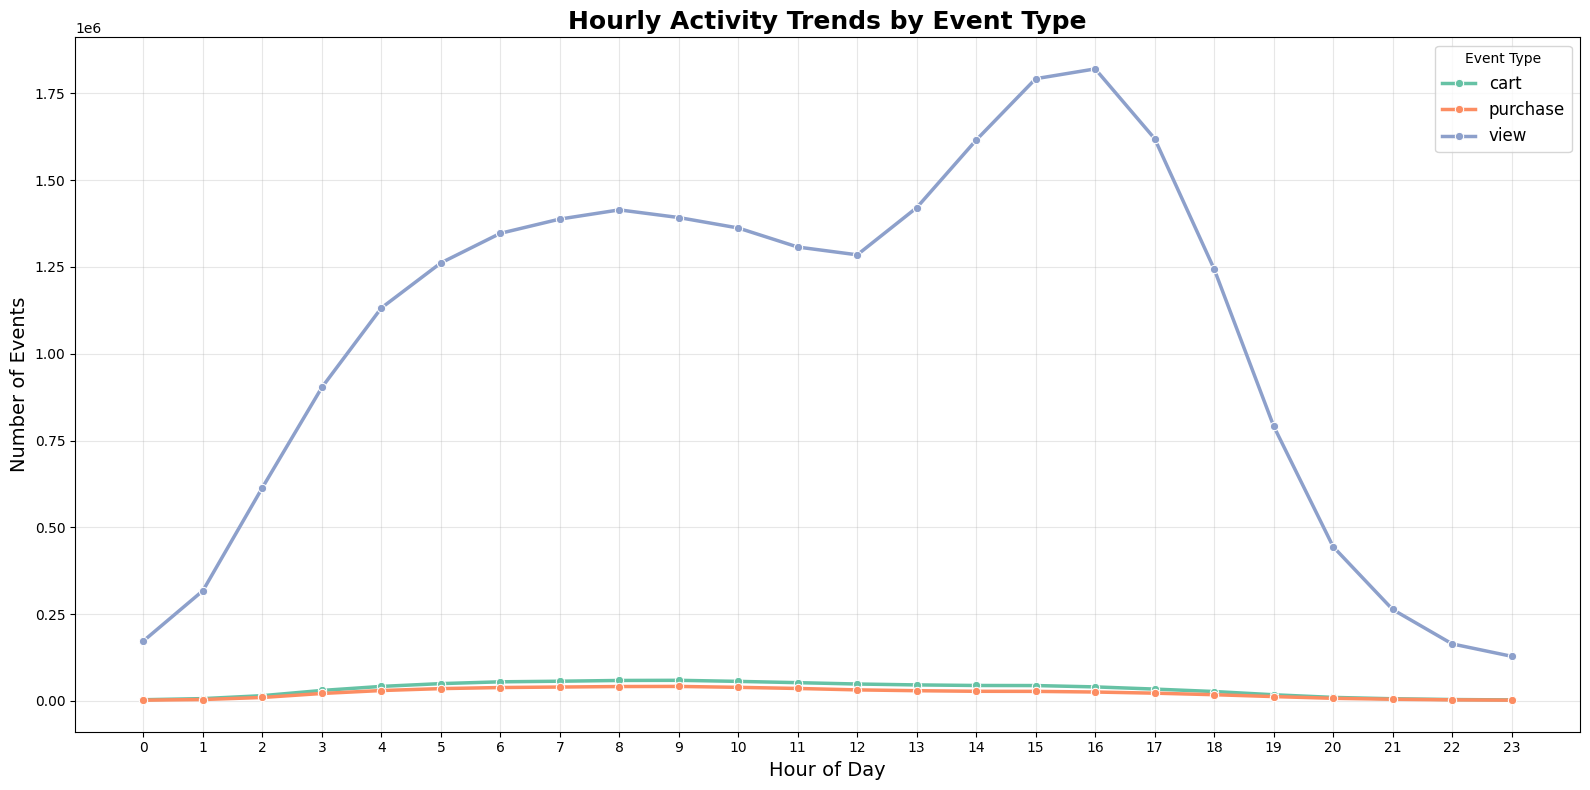

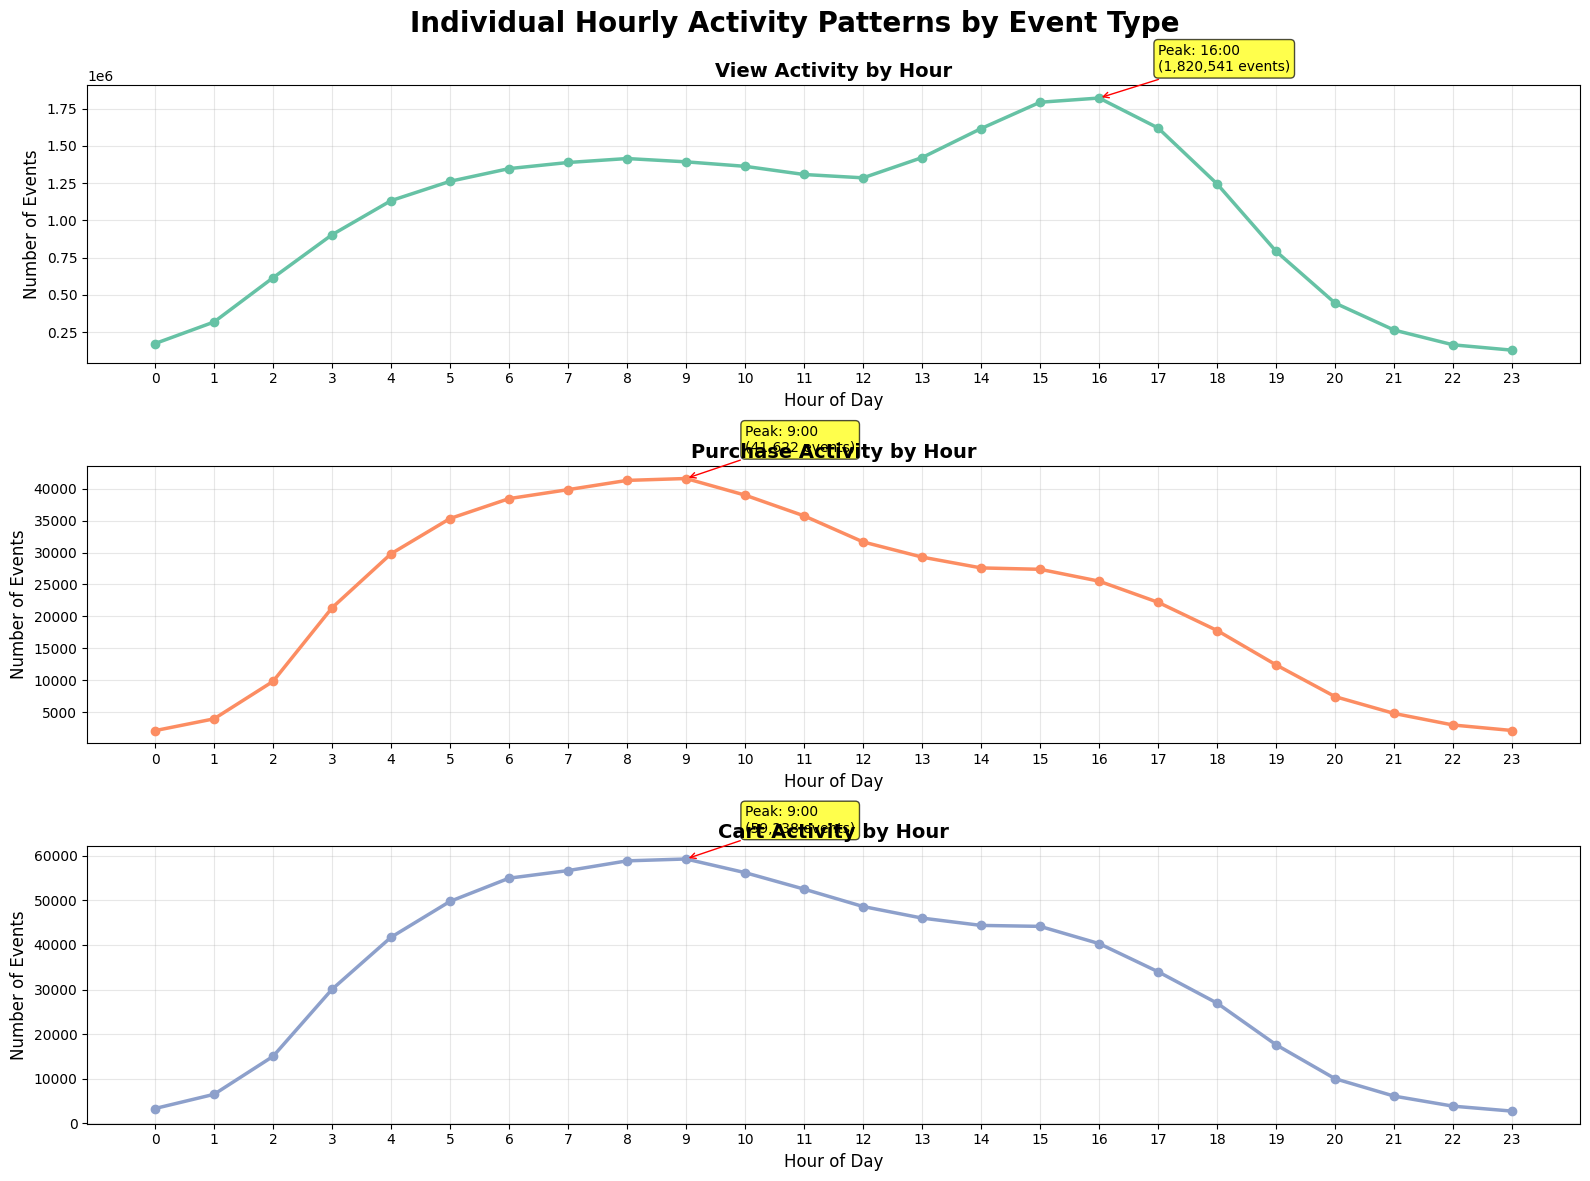

In [6]:
# Hourly Activity Pattern (User Behavior by Hour)
# Combined + Individual line plots — shows overall trend and per-event-type breakdown

# First, convert event_time to datetime
# df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

# Extract hour from event_time for hourly analysis
df['event_hour'] = df['event_time'].dt.hour

# Aggregate event counts by hour and event type
hourly_counts = df.groupby(['event_hour', 'event_type']).size().reset_index(name='count')

# Combined line chart
plt.figure(figsize=(16, 8))
sns.lineplot(data=hourly_counts, x='event_hour', y='count', 
             hue='event_type', marker='o', linewidth=2.5, palette='Set2')
plt.title('Hourly Activity Trends by Event Type', fontsize=18, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.legend(title='Event Type', fontsize=12)
plt.tight_layout()
plt.show()

# Individual line charts for each event type
event_types = df['event_type'].unique()
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

fig, axes = plt.subplots(len(event_types), 1, figsize=(16, 4*len(event_types)))
fig.suptitle('Individual Hourly Activity Patterns by Event Type', fontsize=20, fontweight='bold', y=0.98)

for i, event_type in enumerate(event_types):
    # Filter data for specific event type
    event_data = hourly_counts[hourly_counts['event_type'] == event_type]
    
    # Create line plot
    axes[i].plot(event_data['event_hour'], event_data['count'], 
                 marker='o', linewidth=2.5, color=colors[i], markersize=6)
    
    # Formatting
    axes[i].set_title(f'{event_type.title()} Activity by Hour', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Hour of Day', fontsize=12)
    axes[i].set_ylabel('Number of Events', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xticks(range(0, 24))
    
    # Add peak hour annotation
    peak_hour = event_data.loc[event_data['count'].idxmax()]
    axes[i].annotate(f'Peak: {int(peak_hour["event_hour"])}:00\n({int(peak_hour["count"]):,} events)',
                    xy=(peak_hour['event_hour'], peak_hour['count']),
                    xytext=(peak_hour['event_hour']+1, peak_hour['count']*1.1),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

Total unique buyers:       263,445
One-time buyers:           168,003 (63.8%)
Repeat buyers:             95,442 (36.2%)

Top 5 repeat buyers:
user_id
512386086    322
523974502    288
513320236    242
543312954    193
519267944    183
Name: count, dtype: int64


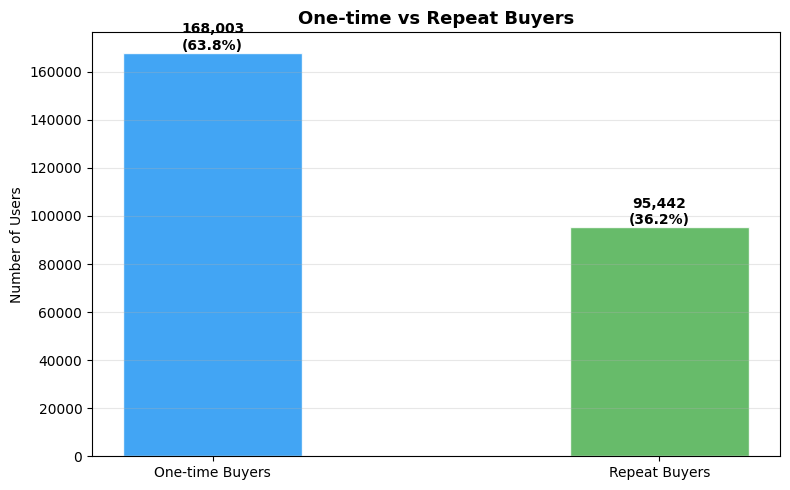

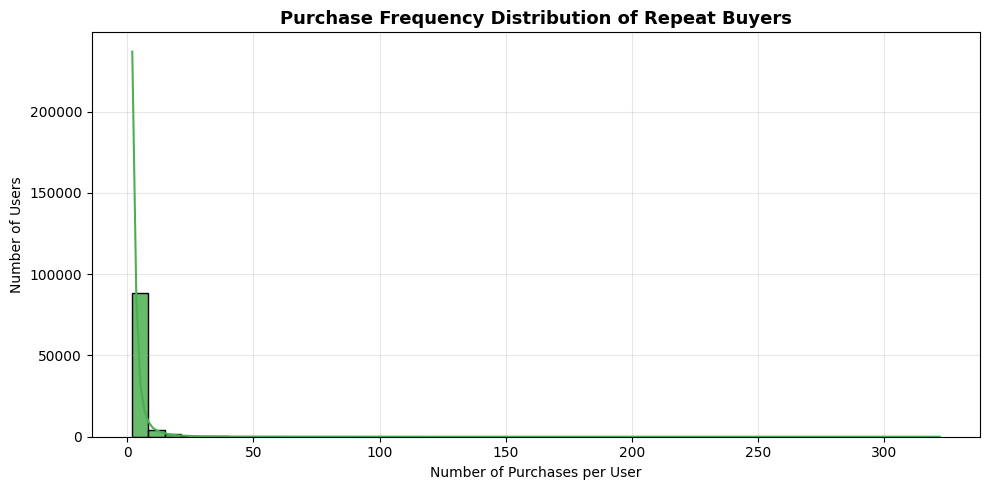

In [7]:
# Repeat Purchase Analysis
# Identifies users who made more than one purchase — key indicator for CLV modelling

# Filter purchase events only
purchase_df = df[df['event_type'] == 'purchase']

# Count purchases per user
user_purchase_counts = purchase_df['user_id'].value_counts()

# Separate repeat buyers (more than 1 purchase) from one-time buyers
repeat_buyers = user_purchase_counts[user_purchase_counts > 1]
one_time_buyers = user_purchase_counts[user_purchase_counts == 1]

print("="*50)
print(f"Total unique buyers:       {len(user_purchase_counts):,}")
print(f"One-time buyers:           {len(one_time_buyers):,} ({len(one_time_buyers)/len(user_purchase_counts)*100:.1f}%)")
print(f"Repeat buyers:             {len(repeat_buyers):,} ({len(repeat_buyers)/len(user_purchase_counts)*100:.1f}%)")
print("="*50)
print(f"\nTop 5 repeat buyers:")
print(repeat_buyers.head())
print("="*50)

# ── Visualization 1: One-time vs Repeat Buyers ───────────────────────
labels = ['One-time Buyers', 'Repeat Buyers']
values = [len(one_time_buyers), len(repeat_buyers)]
colors = ['#2196F3', '#4CAF50']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', width=0.4)

# Add count and percentage labels on top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{val:,}\n({val/len(user_purchase_counts)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('One-time vs Repeat Buyers', fontsize=13, fontweight='bold')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── Visualization 2: Purchase Frequency Distribution of Repeat Buyers ─
plt.figure(figsize=(10, 5))
sns.histplot(repeat_buyers.values, bins=50, color='#4CAF50', alpha=0.85, kde=True)

plt.title('Purchase Frequency Distribution of Repeat Buyers', fontsize=13, fontweight='bold')
plt.xlabel('Number of Purchases per User')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

  Average Order Value (AOV):   $335.15
  Median Order Value:          $215.68
  Minimum Order Value:         $0.88
  Maximum Order Value:         $2574.04
  Total unique buyers:         263,445


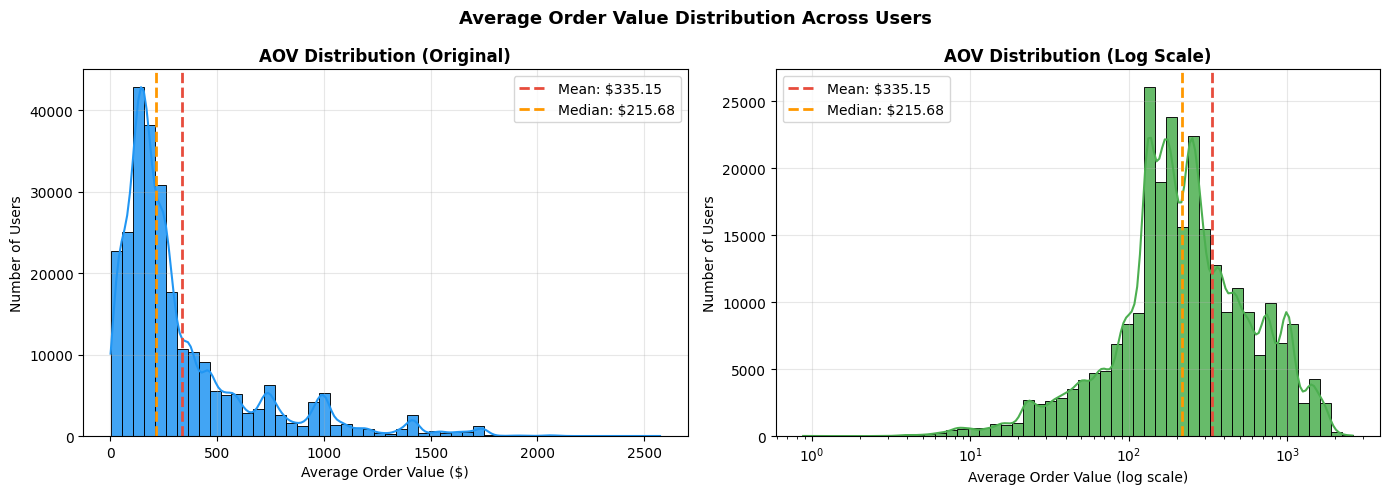

In [8]:
# Average Order Value (AOV) Analysis
# AOV = mean price per purchase transaction across all users

# ── Core Calculation ─────────────────────────────────────────────────

# Average order value per user first, then overall mean
user_aov = purchase_df.groupby('user_id')['price'].mean()  # AOV per individual user
overall_aov = user_aov.mean()                               # Overall AOV across all users
median_aov = user_aov.median()                              # Median AOV — less sensitive to outliers
min_aov = user_aov.min()                                    # Minimum AOV
max_aov = user_aov.max()                                    # Maximum AOV

print("="*50)
print(f"  Average Order Value (AOV):   ${overall_aov:.2f}")
print(f"  Median Order Value:          ${median_aov:.2f}")
print(f"  Minimum Order Value:         ${min_aov:.2f}")
print(f"  Maximum Order Value:         ${max_aov:.2f}")
print(f"  Total unique buyers:         {len(user_aov):,}")
print("="*50)

# ── Visualization: AOV Distribution Across Users ─────────────────────
# Distribution of per-user AOV — reveals spending spread and skew

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Side by side: raw and log scale

# Left: Raw AOV distribution
sns.histplot(user_aov, bins=50, color='#2196F3', alpha=0.85, kde=True, ax=axes[0])
axes[0].axvline(overall_aov, color='#E74C3C', linewidth=2, 
                linestyle='--', label=f'Mean: ${overall_aov:.2f}')   # Mean reference line
axes[0].axvline(median_aov, color='#FF9800', linewidth=2, 
                linestyle='--', label=f'Median: ${median_aov:.2f}')  # Median reference line
axes[0].set_title('AOV Distribution (Original)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Order Value ($)')
axes[0].set_ylabel('Number of Users')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Log scale AOV distribution — handles right skew for clearer shape
sns.histplot(user_aov, bins=50, color='#4CAF50', alpha=0.85, 
             kde=True, log_scale=True, ax=axes[1])
axes[1].axvline(overall_aov, color='#E74C3C', linewidth=2, 
                linestyle='--', label=f'Mean: ${overall_aov:.2f}')
axes[1].axvline(median_aov, color='#FF9800', linewidth=2, 
                linestyle='--', label=f'Median: ${median_aov:.2f}')
axes[1].set_title('AOV Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Order Value (log scale)')
axes[1].set_ylabel('Number of Users')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Average Order Value Distribution Across Users', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Transactional Feature Engineering
# Builds user-level feature matrix from raw event data for CLV modelling
# Features grouped into 4 categories: transactional, behavioural, time-based, category

def engineer_transactional_features(df):

    # ── 1. Transactional Features ────────────────────────────────────
    purchase_data = df[df['event_type'] == 'purchase']  # Filter purchase events only

    # Total spend per user — primary CLV target proxy
    total_purchase_amount = purchase_data.groupby('user_id')['price'].sum().reset_index()
    total_purchase_amount.rename(columns={'price': 'total_purchase_amount'}, inplace=True)

    # Number of purchases per user
    num_purchases = purchase_data.groupby('user_id')['product_id'].count().reset_index()
    num_purchases.rename(columns={'product_id': 'num_purchases'}, inplace=True)

    # Average order value = total spend / number of purchases
    avg_order_value = total_purchase_amount.merge(num_purchases, on='user_id')
    avg_order_value['avg_order_value'] = (avg_order_value['total_purchase_amount'] /
                                          avg_order_value['num_purchases'])

    # ── 2. Behavioural Interaction Features ──────────────────────────
    # Total views per user — measures browsing intensity
    total_views = df[df['event_type'] == 'view'].groupby('user_id')['product_id'].count().reset_index()
    total_views.rename(columns={'product_id': 'total_views'}, inplace=True)

    # Total cart additions per user — measures purchase intent
    total_carts = df[df['event_type'] == 'cart'].groupby('user_id')['product_id'].count().reset_index()
    total_carts.rename(columns={'product_id': 'total_carts'}, inplace=True)

    # Merge view and cart counts — outer join retains all users
    behavior_features = total_views.merge(total_carts, on='user_id', how='outer').fillna(0)
    behavior_features = behavior_features.merge(num_purchases, on='user_id', how='left')

    # Cart abandonment rate = (carts - purchases) / carts
    # Clipped at 0 to avoid negative values from data inconsistencies
    behavior_features['cart_abandonment_rate'] = (
        (behavior_features['total_carts'] - behavior_features['num_purchases'])
        .clip(lower=0) / behavior_features['total_carts'].replace(0, np.nan)
    )

    # Conversion rate = purchases / views
    # replace(0, nan) avoids division by zero for users with no views
    behavior_features['conversion_rate'] = (
        behavior_features['num_purchases'] /
        behavior_features['total_views'].replace(0, np.nan)
    )

    # ── 3. Time-Based Features ───────────────────────────────────────
    # Recency = days since last purchase relative to dataset end date
    last_purchase = purchase_data.groupby('user_id')['event_time'].max().reset_index()
    last_purchase['recency_days'] = (df['event_time'].max() - last_purchase['event_time']).dt.days

    # First purchase gap = days between first view and first purchase
    # Measures how long users take to convert from browsing to buying
    first_view = df[df['event_type'] == 'view'].groupby('user_id')['event_time'].min().reset_index()
    first_purchase = purchase_data.groupby('user_id')['event_time'].min().reset_index()

    purchase_gap = first_view.merge(first_purchase, on='user_id', suffixes=('_view', '_purchase'))
    purchase_gap['first_purchase_gap_days'] = (
        purchase_gap['event_time_purchase'] - purchase_gap['event_time_view']
    ).dt.days

    # ── 4. Category Features ─────────────────────────────────────────
    # Top category = most purchased category per user
    top_category = (purchase_data.groupby(['user_id', 'category_code'])['product_id']
                    .count().reset_index()
                    .sort_values(['user_id', 'product_id'], ascending=[True, False])
                    .drop_duplicates('user_id'))
    top_category.rename(columns={'category_code': 'top_category'}, inplace=True)

    # Category diversity = number of unique categories a user interacted with
    category_diversity = df.groupby('user_id')['category_code'].nunique().reset_index()
    category_diversity.rename(columns={'category_code': 'category_diversity'}, inplace=True)

    # ── 5. Final Merge ───────────────────────────────────────────────
    # Sequentially merge all feature groups on user_id
    final_features = total_purchase_amount.merge(
        avg_order_value[['user_id', 'avg_order_value']], on='user_id', how='left')
    final_features = final_features.merge(
        num_purchases, on='user_id', how='left')
    final_features = final_features.merge(
        behavior_features[['user_id', 'total_views', 'total_carts',
                           'cart_abandonment_rate', 'conversion_rate']], on='user_id', how='left')
    final_features = final_features.merge(
        last_purchase[['user_id', 'recency_days']], on='user_id', how='left')
    final_features = final_features.merge(
        purchase_gap[['user_id', 'first_purchase_gap_days']], on='user_id', how='left')
    final_features = final_features.merge(
        top_category[['user_id', 'top_category']], on='user_id', how='left')
    final_features = final_features.merge(
        category_diversity, on='user_id', how='left')

    # Fill remaining NaN with 0 — users missing certain event types default to 0
    return final_features.fillna(0)

# Run transactional feature engineering and store result
trans_df = engineer_transactional_features(df)
print(f"Transactional feature matrix shape : {trans_df.shape}")
print(f"Features: {list(trans_df.columns)}")
print("\nSample output:")
print(trans_df.head())

Transactional feature matrix shape : (263445, 12)
Features: ['user_id', 'total_purchase_amount', 'avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'top_category', 'category_diversity']

Sample output:
     user_id  total_purchase_amount  avg_order_value  num_purchases  \
0  303160429                 340.59           340.59              1   
1  340041246                 339.70           339.70              1   
2  384989212                  41.44            41.44              1   
3  401021311                 231.64           231.64              1   
4  403013066                 807.16           403.58              2   

   total_views  total_carts  cart_abandonment_rate  conversion_rate  \
0          2.0          0.0               0.000000         0.500000   
1         28.0          0.0               0.000000         0.035714   
2        128.0          0.0               0.000000      

In [10]:
# Behavioural Feature Engineering
# Builds user-level behavioural features from session and event interaction data
# Features grouped into: session-level, event counts, and funnel ratios
# Note: total_purchase_amount is handled in transactional features — not duplicated here

def engineer_behavioural_features(df):

    # ── 1. Session-Level Features ────────────────────────────────────
    user_summary = df.groupby('user_id').agg(
        sessions_per_user  = ('user_session', 'nunique'),          # Number of unique sessions per user
        active_duration    = ('event_time', lambda x:
                              (x.max() - x.min()).total_seconds()), # Total active time in seconds
        category_diversity = ('category_code', pd.Series.nunique)  # Number of unique categories browsed
    ).reset_index()

    # ── 2. Event Type Counts ─────────────────────────────────────────
    # Pivot to get view, cart, purchase counts as separate columns per user
    event_counts = df.pivot_table(
        index='user_id',
        columns='event_type',
        aggfunc='size',
        fill_value=0
    ).reset_index()
    event_counts.columns.name = None  # Remove MultiIndex column name for clean merging

    # Ensure all three event type columns exist — handles edge cases where
    # a user may have no cart or purchase events
    for col in ['view', 'cart', 'purchase']:
        if col not in event_counts.columns:
            event_counts[col] = 0

    # Rename for clarity
    event_counts = event_counts.rename(columns={
        'view'    : 'view_count',
        'cart'    : 'cart_count',
        'purchase': 'purchase_count'
    })

    # ── 3. Funnel Ratio Features ─────────────────────────────────────
    # Cart-to-view ratio — measures browsing to cart conversion tendency
    # replace(0,1) avoids division by zero for users with no views
    event_counts['cart_to_view_ratio'] = (
        event_counts['cart_count'] / event_counts['view_count'].replace(0, 1)
    )

    # Purchase rate — measures overall conversion from browsing to purchase
    event_counts['purchase_rate'] = (
        event_counts['purchase_count'] / event_counts['view_count'].replace(0, 1)
    )

    # ── 4. Merge Session and Event Features ──────────────────────────
    behavioural_df = user_summary.merge(event_counts, on='user_id', how='left')

    # ── 5. Data Quality Filters ──────────────────────────────────────
    # Replace inf values from ratio calculations with 0
    behavioural_df = behavioural_df.replace([np.inf, -np.inf], 0).fillna(0)

    # Remove users with no views — insufficient behavioural data for modelling
    behavioural_df = behavioural_df[behavioural_df['view_count'] > 0]

    return behavioural_df

# Run behavioural feature engineering and store result
beh_df = engineer_behavioural_features(df)
print(f"Behavioural feature matrix shape: {beh_df.shape}")
print(f"Features: {list(beh_df.columns)}")
print("\nSample output:")
print(beh_df.head())

Behavioural feature matrix shape: (2322867, 9)
Features: ['user_id', 'sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']

Sample output:
     user_id  sessions_per_user  active_duration  category_diversity  \
0   33869381                  1              0.0                   1   
1  184265397                  1            387.0                   1   
2  195082191                  1              0.0                   1   
3  200673532                  3         257025.0                   2   
4  208669541                  1              0.0                   1   

   cart_count  purchase_count  view_count  cart_to_view_ratio  purchase_rate  
0           0               0           1                 0.0            0.0  
1           0               0           4                 0.0            0.0  
2           0               0           1                 0.0            0.0  
3           0      

In [11]:
# Merging Transactional and Behavioural Feature Sets

# Identify and remove overlapping columns from beh_df before merging
overlapping_columns = set(trans_df.columns) & set(beh_df.columns) - {'user_id'}
print(f"Overlapping columns removed from beh_df: {overlapping_columns}")

# Drop overlapping columns from beh_df — transactional version takes priority
beh_df_cleaned = beh_df.drop(columns=overlapping_columns)

# Merge cleaned DataFrames
hybrid_df = pd.merge(trans_df, beh_df_cleaned, on='user_id', how='inner')

print(f"\nTransactional features shape : {trans_df.shape}")
print(f"Behavioural features shape   : {beh_df.shape}")
print(f"Merged hybrid matrix shape   : {hybrid_df.shape}")
print(f"\nAll features: {list(hybrid_df.columns)}")
print(hybrid_df.head())

Overlapping columns removed from beh_df: {'category_diversity'}

Transactional features shape : (263445, 12)
Behavioural features shape   : (2322867, 9)
Merged hybrid matrix shape   : (263380, 19)

All features: ['user_id', 'total_purchase_amount', 'avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'top_category', 'category_diversity', 'sessions_per_user', 'active_duration', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']
     user_id  total_purchase_amount  avg_order_value  num_purchases  \
0  303160429                 340.59           340.59              1   
1  340041246                 339.70           339.70              1   
2  384989212                  41.44            41.44              1   
3  401021311                 231.64           231.64              1   
4  403013066                 807.16           403.58              2   

   total

Features available for plotting: ['avg_order_value', 'num_purchases', 'category_diversity', 'total_views', 'cart_abandonment_rate', 'conversion_rate', 'total_carts', 'recency_days', 'first_purchase_gap_days']


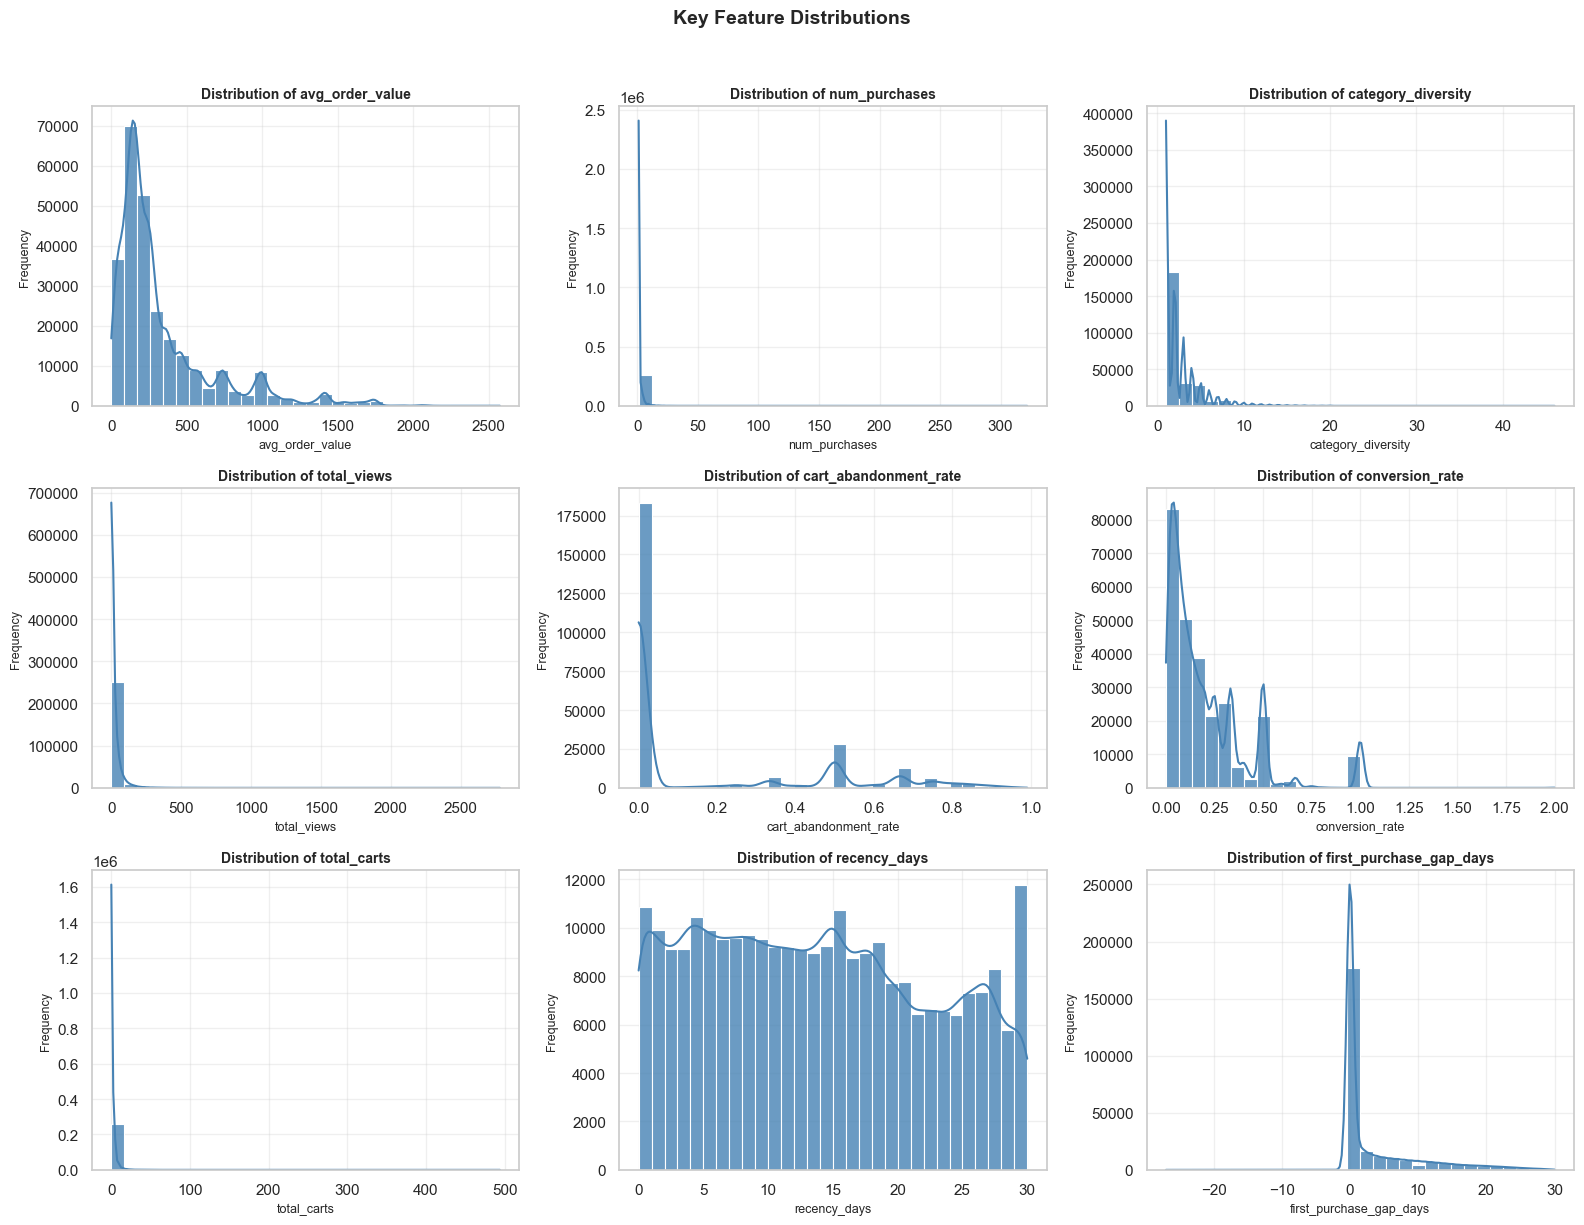

C:\Users\shire\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\shire\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\shire\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\shire\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


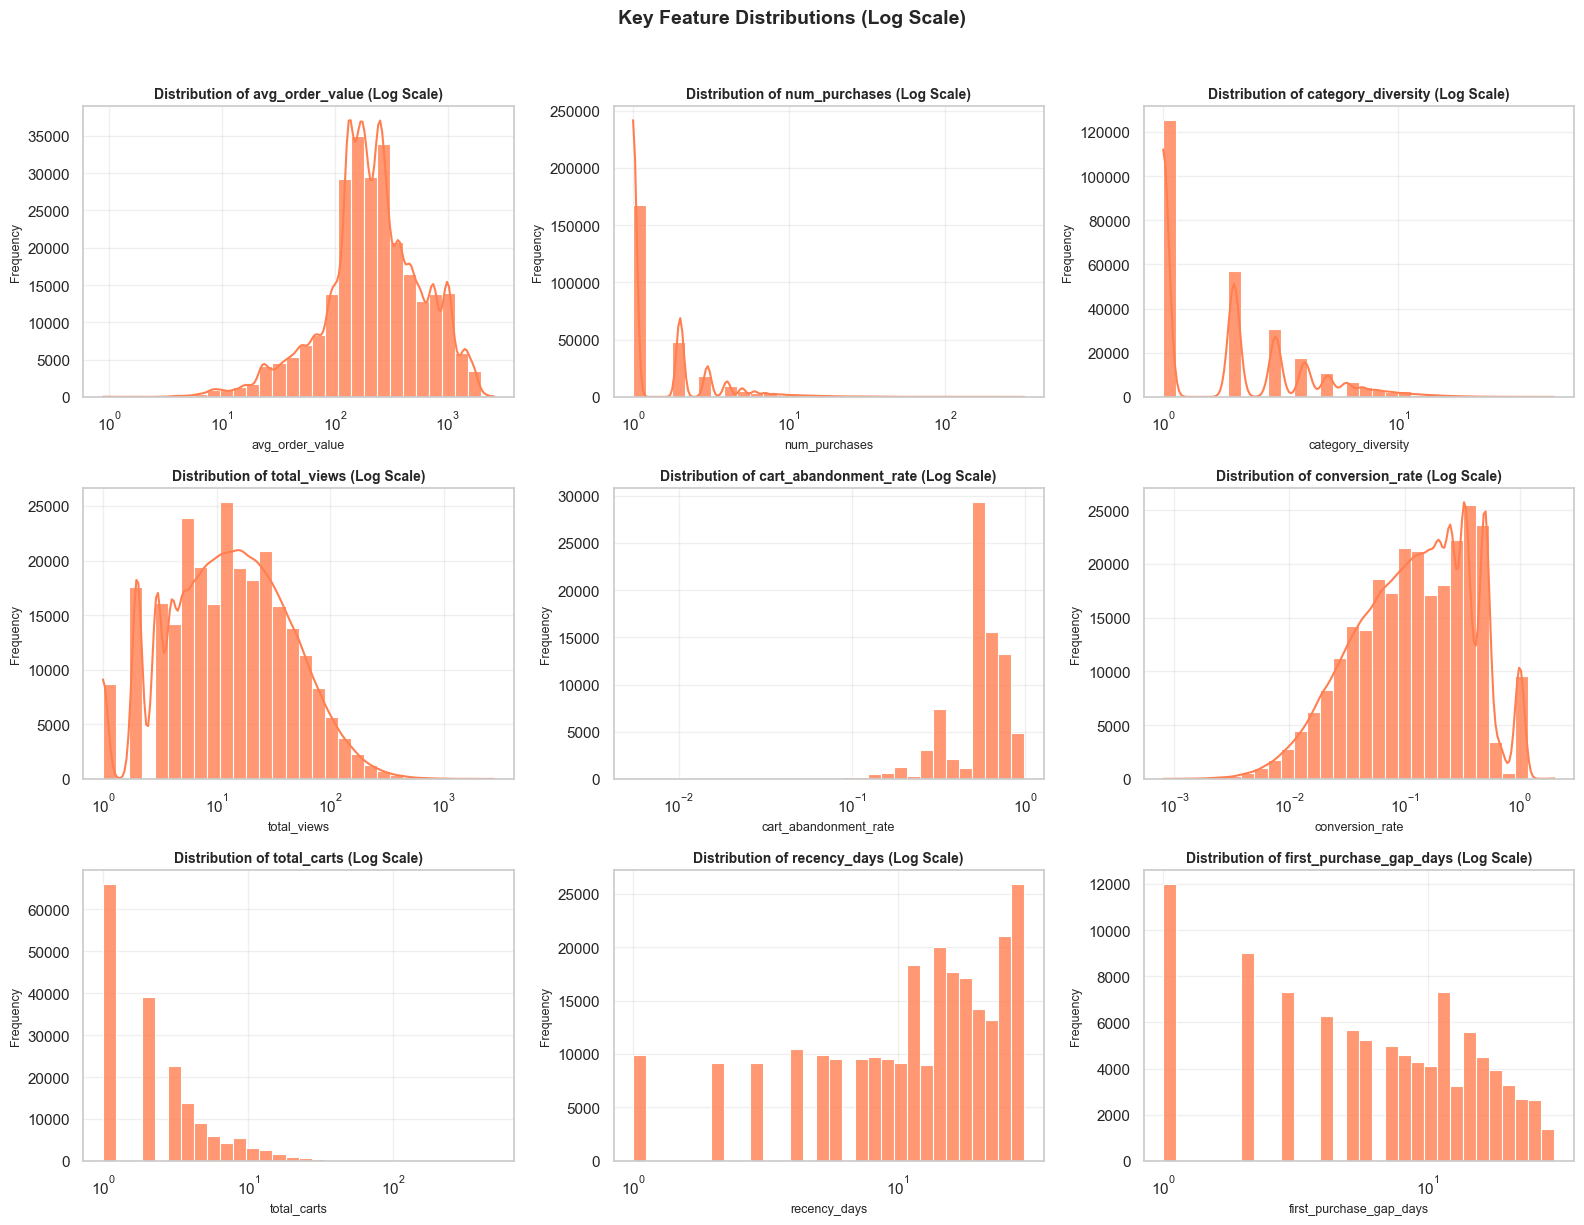

In [12]:
# Visualising key feature distributions
# Grid layout — all 9 numeric features in one figure for compact academic presentation

sns.set(style="whitegrid")

# Verify all features exist in hybrid_df before plotting
numeric_features = [f for f in [
    'avg_order_value', 'num_purchases', 'category_diversity', 'total_views',
    'cart_abandonment_rate', 'conversion_rate', 'total_carts',
    'recency_days', 'first_purchase_gap_days'
] if f in hybrid_df.columns]  # Only keep features that actually exist

print(f"Features available for plotting: {numeric_features}")

# ── Option 1: 3x3 Grid (Recommended) ────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))  # 3 rows x 3 columns grid
axes = axes.flatten()                              # Flatten to iterate easily

for i, feature in enumerate(numeric_features):
    sns.histplot(hybrid_df[feature], kde=True, bins=30, 
                 color='steelblue', alpha=0.8, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Option 2: Log Scale Grid (Better for skewed features) ────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(hybrid_df[feature], kde=True, bins=30,
                 color='coral', alpha=0.8, ax=axes[i], log_scale=True)  # Log scale handles right skew
    axes[i].set_title(f'Distribution of {feature} (Log Scale)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Key Feature Distributions (Log Scale)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Features included in correlation matrix: ['avg_order_value', 'num_purchases', 'category_diversity', 'total_views', 'cart_abandonment_rate', 'conversion_rate', 'total_carts', 'recency_days', 'first_purchase_gap_days', 'total_purchase_amount']


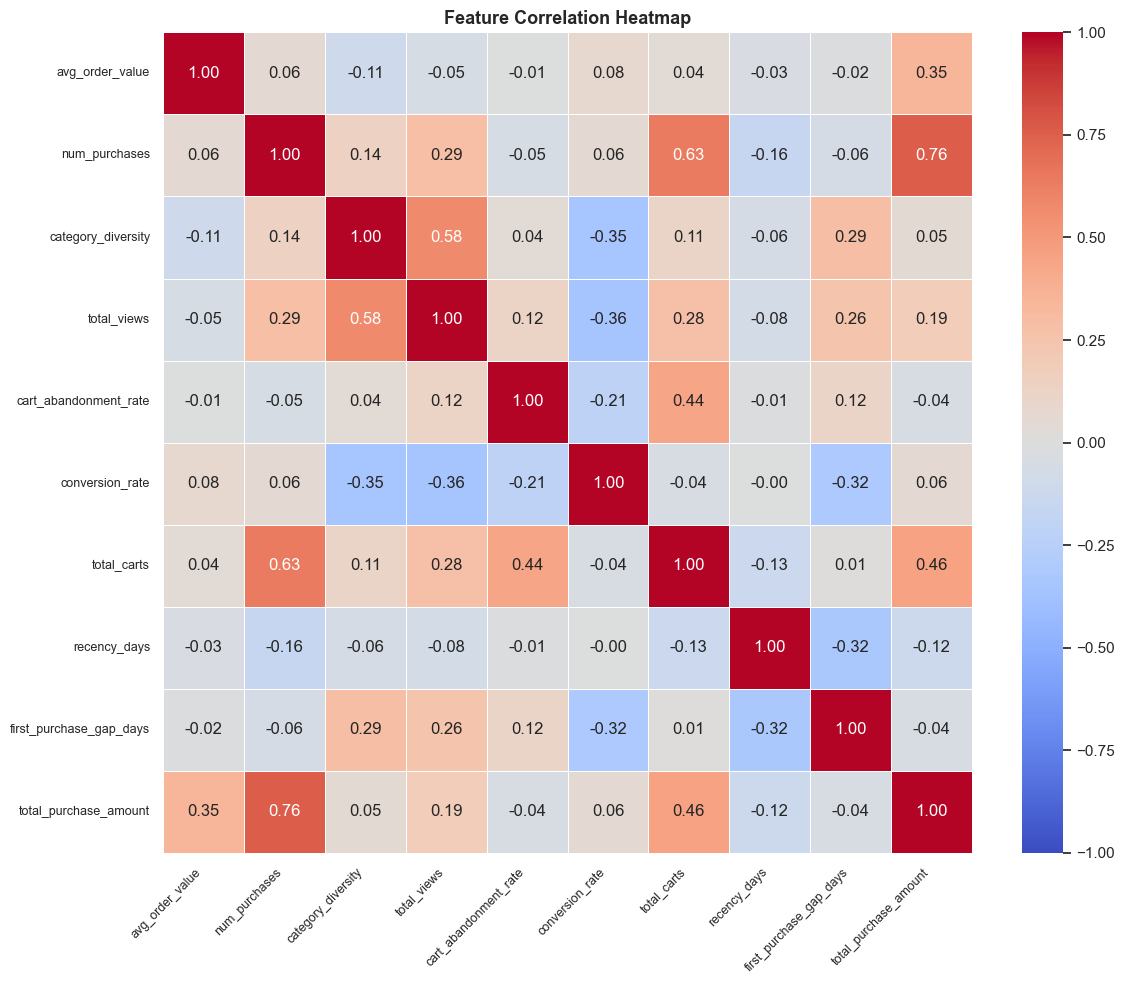

In [13]:
# Correlation Heatmap
# Shows pairwise correlation between all numeric features and CLV target variable
# Helps identify multicollinearity and strongest predictors of total_purchase_amount

import warnings

# Build feature list — only include columns that actually exist in hybrid_df
corr_features = [f for f in numeric_features + ['total_purchase_amount'] 
                 if f in hybrid_df.columns]

print(f"Features included in correlation matrix: {corr_features}")

# Suppress RuntimeWarning from NaN values during correlation calculation
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    corr = hybrid_df[corr_features].corr()  # Compute pairwise Pearson correlation

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,           # Show correlation values inside each cell
            cmap='coolwarm',      # Red = positive, Blue = negative correlation
            fmt='.2f',            # Round to 2 decimal places
            linewidths=0.5,       # Grid lines between cells
            linecolor='white',    # White grid lines for clean separation
            vmin=-1, vmax=1)      # Fix scale to full correlation range

plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)   # Rotate x labels to prevent overlap
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

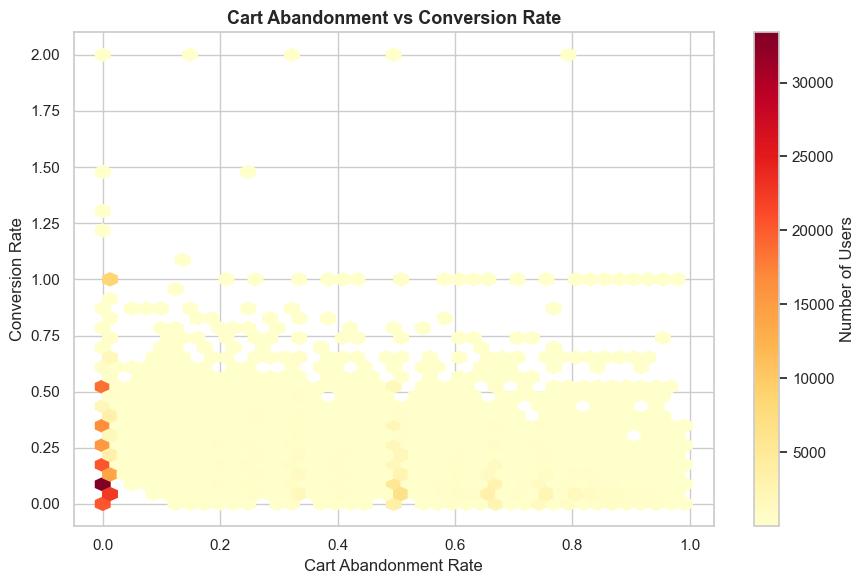

In [14]:
# Cart Abandonment vs Conversion Rate
# Hexbin plot — handles overplotting on large datasets by grouping points into hex bins
# Darker hexagons = higher density of users in that region

plt.figure(figsize=(9, 6))
plt.hexbin(hybrid_df['cart_abandonment_rate'],
           hybrid_df['conversion_rate'],
           gridsize=40,              # Number of hexagons across x-axis
           cmap='YlOrRd',            # Yellow to Red — darker = more users
           mincnt=1)                 # Only show hexagons with at least 1 user

plt.colorbar(label='Number of Users')  # Color scale legend
plt.title('Cart Abandonment vs Conversion Rate', fontsize=13, fontweight='bold')
plt.xlabel('Cart Abandonment Rate')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

In [15]:
# Save both feature sets
beh_df.to_csv('../data/behavioural_features.csv', index=False)
trans_df.to_csv('../data/transactional_features.csv', index=False)
hybrid_df.to_csv('../data/hybrid_features.csv', index=False)

print("All feature datasets saved!")

All feature datasets saved!
